# CSC3831 Coursework Part 3: Deep Learning

## Imports

In [19]:
import torch
import torch.nn as nn 
from torch.utils.data import DataLoader, random_split 
from torchvision import datasets, transforms 
from torchvision.transforms import ToTensor
import torchvision
import torch.optim as optim
import torch.nn.functional as F
import copy
import numpy as np 
import matplotlib.pyplot as plt 

## Use GPU

In [20]:
if torch.cuda.is_available():
    print('Using GPU, device name:', torch.cuda.get_device_name(0))
    device = torch.device('cuda')
else:
    print('No GPU found, using CPU instead.')
    device = torch.device('cpu')

Using GPU, device name: NVIDIA GeForce RTX 3060 Laptop GPU


## CIFAR-10 Data Loading

In [21]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_dataset = datasets.CIFAR10(root='data', train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR10(root='data', train=False, download=True, transform=transform)

train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=120, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=120, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=120, shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

print(f'Train samples: {len(train_dataset)}, Val samples: {len(val_dataset)}, Test samples: {len(test_dataset)}')

Train samples: 40000, Val samples: 10000, Test samples: 10000


## Part 1

In [22]:
class MyCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(3, 64, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(64, 128, 3, padding=1)
        self.conv3 = nn.Conv2d(128, 256, 3, padding=1)
        
        self.fc1 = nn.Linear(256 * 4 * 4, 1024)
        self.fc2 = nn.Linear(1024, 512)
        self.fc3 = nn.Linear(512, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

model = MyCNN()
print(model)

MyCNN(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=4096, out_features=1024, bias=True)
  (fc2): Linear(in_features=1024, out_features=512, bias=True)
  (fc3): Linear(in_features=512, out_features=10, bias=True)
)


In [23]:
def epoch_train(model, train_loader, criterion, optimizer):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc

In [24]:
def model_evaluation(model, val_loader, criterion):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    
    epoch_loss = running_loss / len(val_loader)
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc

In [25]:
def early_stopping(model, train_loader, val_loader, optimizer):
    epochs = 50
    patience = 15
    min_delta = 0.001
    criterion = nn.CrossEntropyLoss()
    
    best_val_loss = 999999999999
    best_model_state = None
    best_epoch = -1
    best_val_acc = 0.0
    patience_counter = 0
    
    train_losses = []
    val_losses = []
    train_accuracy = []
    val_accuracy = []
    
    for epoch in range(epochs):
        train_loss, train_acc = epoch_train(model, train_loader, criterion, optimizer)
        val_loss, val_acc = model_evaluation(model, val_loader, criterion)
        
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accuracy.append(train_acc)
        val_accuracy.append(val_acc)
        
        print(f'(Epoch: {epoch+1}/{epochs}) Training Loss: {train_loss:.4f}, Training Accuracy: {train_acc:.4f}%, '
              f'Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_acc:.4f}%')
        
        if val_loss < best_val_loss - min_delta:
            best_val_loss = val_loss
            best_model_state = copy.deepcopy(model.state_dict())
            best_epoch = epoch + 1
            best_val_acc = val_acc
            patience_counter = 0
            print(f'- Validation loss improved - Model saved')
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f'\nEarly stopping triggered after {epoch+1} epochs')
                print(f'No improvement in validation loss after 15 consecutive epochs')
                break
    
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        print('\nTraining Complete:')
        print(f'Best Epoch: {best_epoch}')
        print(f'Best Validation Loss: {best_val_loss:.4f}')
        print(f'Best Validation Accuracy: {best_val_acc:.4f}%')
    
    return train_losses, val_losses, train_accuracy, val_accuracy

In [26]:
model_task1 = MyCNN().to(device)
optimizer = optim.Adam(model_task1.parameters(), lr=0.001)

train_losses_1, val_losses_1, train_accuracy_1, val_accuracy_1 = early_stopping(
    model_task1, train_loader, val_loader, optimizer)

(Epoch: 1/50) Training Loss: 1.4769, Training Accuracy: 45.6025%, Validation Loss: 1.1809, Validation Accuracy: 56.3900%
- Validation loss improved - Model saved
(Epoch: 2/50) Training Loss: 0.9853, Training Accuracy: 64.6050%, Validation Loss: 1.0299, Validation Accuracy: 63.4400%
- Validation loss improved - Model saved
(Epoch: 3/50) Training Loss: 0.7582, Training Accuracy: 73.1075%, Validation Loss: 0.8331, Validation Accuracy: 71.1800%
- Validation loss improved - Model saved
(Epoch: 4/50) Training Loss: 0.5893, Training Accuracy: 79.3525%, Validation Loss: 0.7707, Validation Accuracy: 73.7500%
- Validation loss improved - Model saved
(Epoch: 5/50) Training Loss: 0.4355, Training Accuracy: 84.7875%, Validation Loss: 0.7800, Validation Accuracy: 74.7400%
(Epoch: 6/50) Training Loss: 0.2977, Training Accuracy: 89.5875%, Validation Loss: 0.9142, Validation Accuracy: 73.5700%
(Epoch: 7/50) Training Loss: 0.2002, Training Accuracy: 92.9525%, Validation Loss: 0.9816, Validation Accuracy

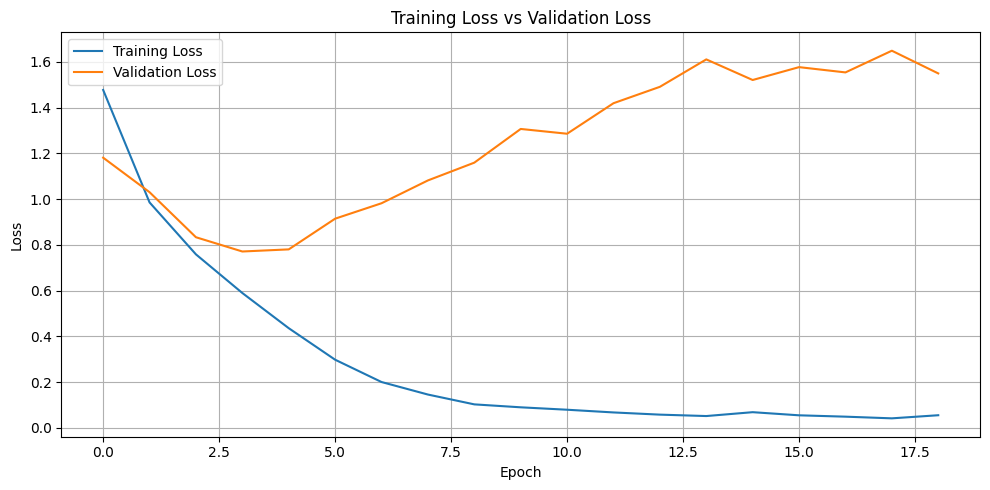

In [38]:
plt.figure(figsize=(10, 5))

plt.plot(train_losses_1, label='Training Loss')
plt.plot(val_losses_1, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss vs Validation Loss')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## Part 2

In [28]:
class MyCNNDropout(nn.Module):
    def __init__(self):
        super(MyCNNDropout, self).__init__()
        self.conv1 = nn.Conv2d(3, 64, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(64, 128, 3, padding=1)
        self.conv3 = nn.Conv2d(128, 256, 3, padding=1)
        
        self.fc1 = nn.Linear(256 * 4 * 4, 1024)
        self.fc2 = nn.Linear(1024, 512)
        self.fc3 = nn.Linear(512, 10)
        
        self.dropout = nn.Dropout(p=0.5) 

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = torch.flatten(x, 1)
        x = self.dropout(x)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [29]:
model_dropout = MyCNNDropout().to(device)

optimizer_dropout = optim.Adam(model_dropout.parameters(), lr=0.001)

train_losses_dropout, val_losses_dropout, train_accuracy_dropout, val_accuracy_dropout = early_stopping(
    model_dropout, train_loader, val_loader, optimizer_dropout
)

(Epoch: 1/50) Training Loss: 1.5414, Training Accuracy: 43.1250%, Validation Loss: 1.2606, Validation Accuracy: 53.8500%
- Validation loss improved - Model saved
(Epoch: 2/50) Training Loss: 1.1422, Training Accuracy: 59.1225%, Validation Loss: 0.9620, Validation Accuracy: 65.5800%
- Validation loss improved - Model saved
(Epoch: 3/50) Training Loss: 0.9553, Training Accuracy: 66.4200%, Validation Loss: 0.8667, Validation Accuracy: 69.6900%
- Validation loss improved - Model saved
(Epoch: 4/50) Training Loss: 0.8361, Training Accuracy: 70.8375%, Validation Loss: 0.7737, Validation Accuracy: 73.0400%
- Validation loss improved - Model saved
(Epoch: 5/50) Training Loss: 0.7544, Training Accuracy: 73.3125%, Validation Loss: 0.7525, Validation Accuracy: 74.0200%
- Validation loss improved - Model saved
(Epoch: 6/50) Training Loss: 0.6908, Training Accuracy: 75.7300%, Validation Loss: 0.6811, Validation Accuracy: 76.6600%
- Validation loss improved - Model saved
(Epoch: 7/50) Training Loss:

In [30]:
model_l2 = MyCNN().to(device) 

optimizer_l2 = optim.Adam(model_l2.parameters(), lr=0.001, weight_decay=1e-4)

train_loss_l2, val_loss_l2, train_accuracy_l2, val_accuracy_l2 = early_stopping(
    model_l2, train_loader, val_loader, optimizer_l2
)

(Epoch: 1/50) Training Loss: 1.4713, Training Accuracy: 45.9325%, Validation Loss: 1.1973, Validation Accuracy: 57.4700%
- Validation loss improved - Model saved
(Epoch: 2/50) Training Loss: 1.0022, Training Accuracy: 64.4025%, Validation Loss: 0.9441, Validation Accuracy: 66.6200%
- Validation loss improved - Model saved
(Epoch: 3/50) Training Loss: 0.7860, Training Accuracy: 72.2175%, Validation Loss: 0.8081, Validation Accuracy: 71.9700%
- Validation loss improved - Model saved
(Epoch: 4/50) Training Loss: 0.6313, Training Accuracy: 77.8025%, Validation Loss: 0.7984, Validation Accuracy: 72.6200%
- Validation loss improved - Model saved
(Epoch: 5/50) Training Loss: 0.5083, Training Accuracy: 82.0125%, Validation Loss: 0.8154, Validation Accuracy: 74.0800%
(Epoch: 6/50) Training Loss: 0.3765, Training Accuracy: 86.7775%, Validation Loss: 0.7762, Validation Accuracy: 75.1200%
- Validation loss improved - Model saved
(Epoch: 7/50) Training Loss: 0.2767, Training Accuracy: 90.2275%, Val

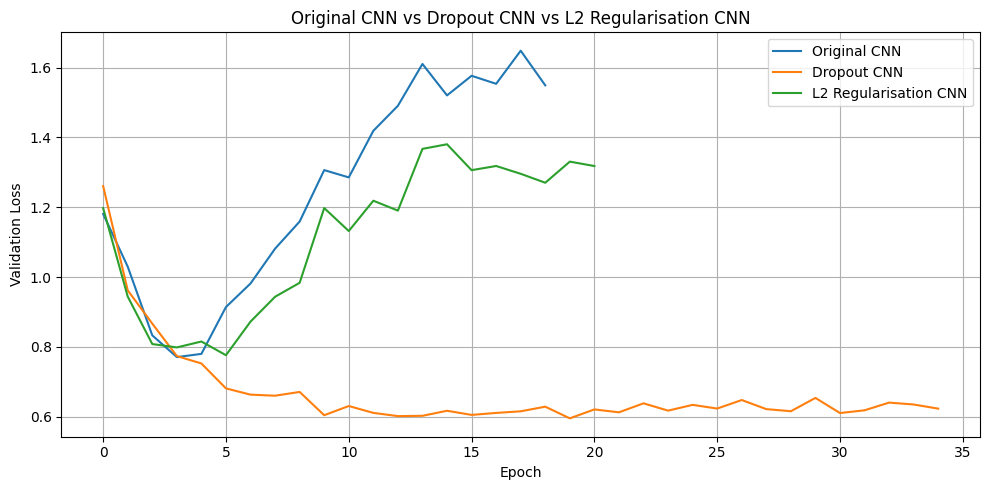

In [36]:
plt.figure(figsize=(10, 5))

plt.plot(val_losses_1, label='Original CNN')
plt.plot(val_losses_dropout, label='Dropout CNN')
plt.plot(val_loss_l2, label='L2 Regularisation CNN')
plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.title('Original CNN vs Dropout CNN vs L2 Regularisation CNN')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## Part 3

In [34]:
class MyCNNBatchNorm(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 64, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(64)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(64, 128, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(128)
        self.conv3 = nn.Conv2d(128, 256, 3, padding=1)
        self.bn3 = nn.BatchNorm2d(256)

        self.fc1 = nn.Linear(256 * 4 * 4, 1024)
        self.fc2 = nn.Linear(1024, 512)
        self.fc3 = nn.Linear(512, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        
        x = torch.flatten(x, 1)
        
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [35]:
model_batchnorm = MyCNNBatchNorm().to(device)
optimizer_batchnorm = optim.Adam(model_batchnorm.parameters(), lr=0.001)

train_losses_batchnorm, val_losses_batchnorm, train_accuracy_batchnorm, val_accuracy_batchnorm = early_stopping(
    model_batchnorm, train_loader, val_loader, optimizer_batchnorm
)

(Epoch: 1/50) Training Loss: 1.3532, Training Accuracy: 50.4725%, Validation Loss: 1.1409, Validation Accuracy: 59.4700%
- Validation loss improved - Model saved
(Epoch: 2/50) Training Loss: 0.8967, Training Accuracy: 68.0525%, Validation Loss: 0.8969, Validation Accuracy: 68.5400%
- Validation loss improved - Model saved
(Epoch: 3/50) Training Loss: 0.7146, Training Accuracy: 74.7775%, Validation Loss: 0.8837, Validation Accuracy: 68.6900%
- Validation loss improved - Model saved
(Epoch: 4/50) Training Loss: 0.5918, Training Accuracy: 79.2300%, Validation Loss: 0.7406, Validation Accuracy: 74.9800%
- Validation loss improved - Model saved
(Epoch: 5/50) Training Loss: 0.4956, Training Accuracy: 82.6175%, Validation Loss: 0.7171, Validation Accuracy: 76.6100%
- Validation loss improved - Model saved
(Epoch: 6/50) Training Loss: 0.4017, Training Accuracy: 85.8900%, Validation Loss: 0.6814, Validation Accuracy: 77.3200%
- Validation loss improved - Model saved
(Epoch: 7/50) Training Loss:

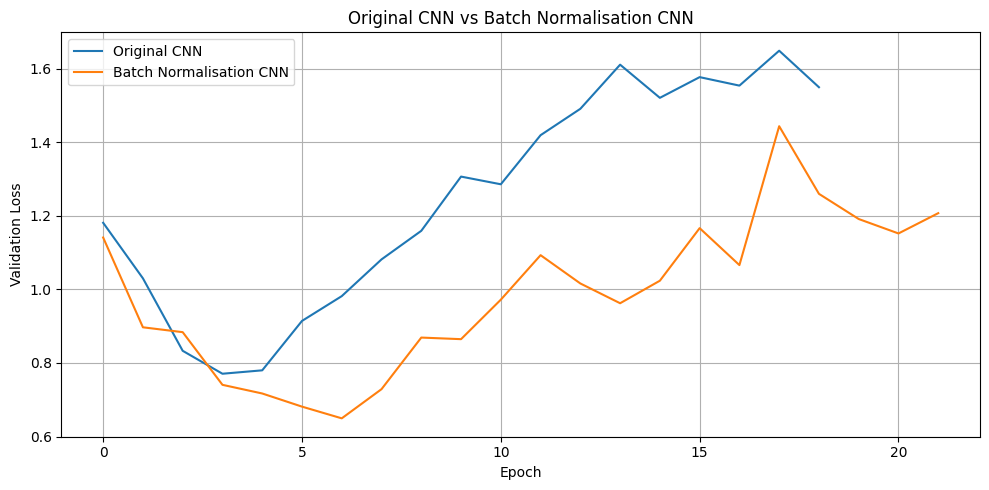

In [37]:
plt.figure(figsize=(10, 5))

plt.plot(val_losses_1, label='Original CNN')
plt.plot(val_losses_batchnorm, label='Batch Normalisation CNN')
plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.title('Original CNN vs Batch Normalisation CNN')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## Task 4

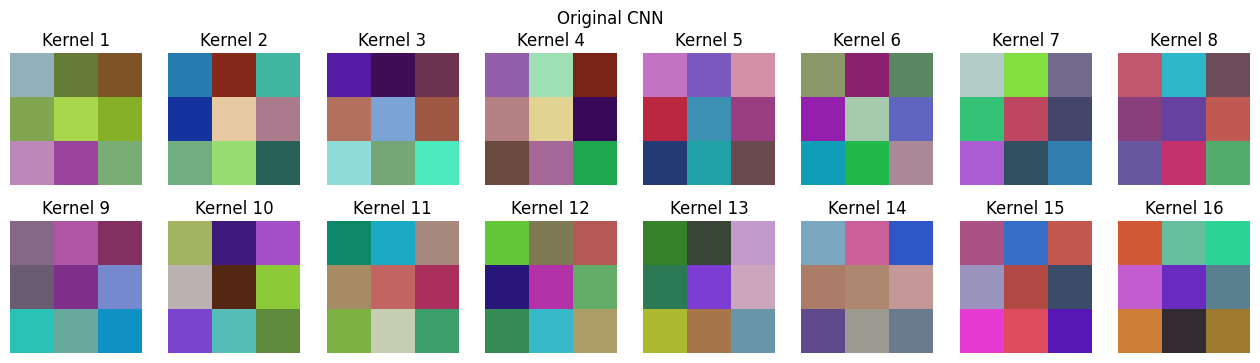

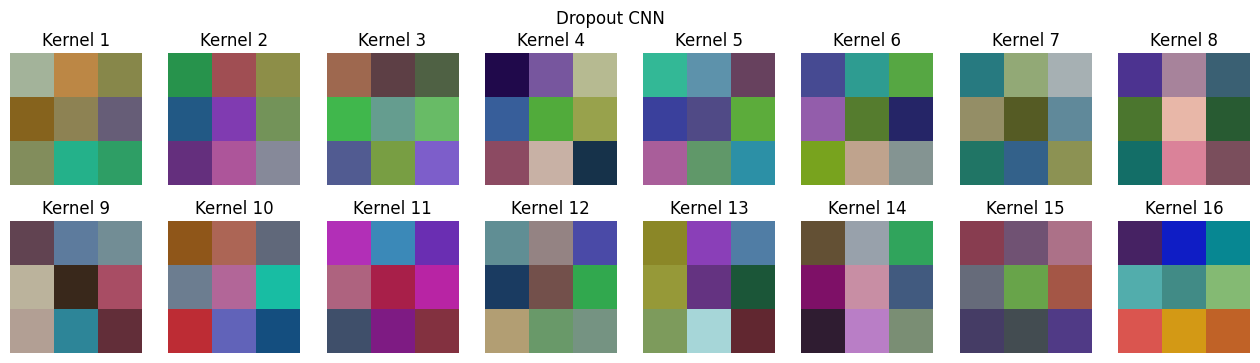

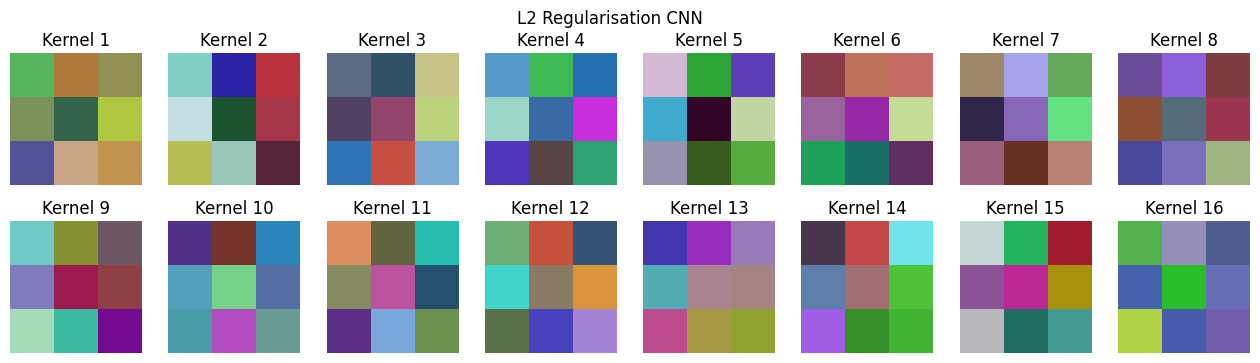

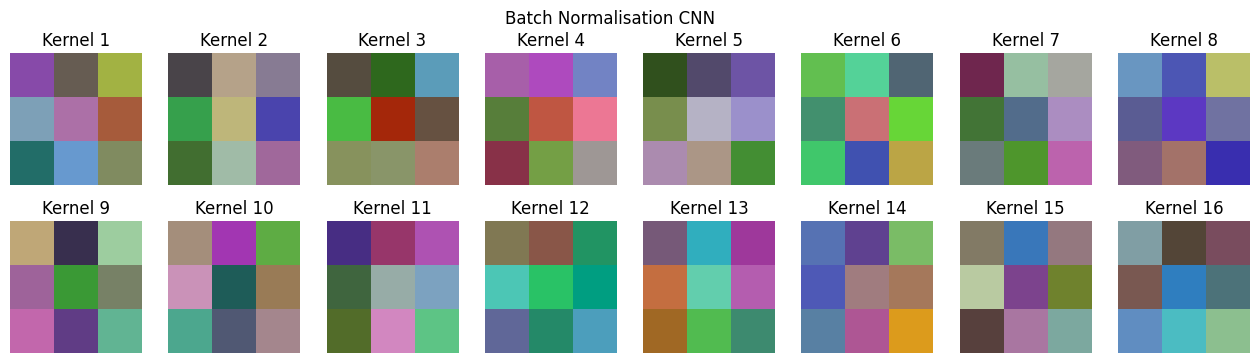

In [48]:
def visualise_filters(model, name):
    filters = model.conv1.weight.detach().cpu()
    
    filters = filters - filters.min()
    filters = filters / filters.max()
    
    num_filters = 16 

    fig, axes = plt.subplots(2, 8, figsize=(16, 4))
    
    for i, ax in enumerate(axes.flat):
        if i < num_filters:

            k = filters[i].permute(1, 2, 0).numpy()
            
            ax.imshow(k)
            ax.set_title(f'Kernel {i+1}')
            ax.axis('off')
            
    plt.suptitle(f"{name}")
    plt.show()

visualise_filters(model_task1, "Original CNN")
visualise_filters(model_dropout, "Dropout CNN")
visualise_filters(model_l2, "L2 Regularisation CNN")
visualise_filters(model_batchnorm, "Batch Normalisation CNN")

In [50]:
def visualize_feature_maps(model, name, loader):
    model.eval()

    dataiter = iter(loader)
    images, labels = next(dataiter)
    
    test_image = images[0].unsqueeze(0).to(device)
    
    plt.figure(figsize=(3, 3))
    img_display = images[0].permute(1, 2, 0).cpu().numpy()
    img_display = (img_display - img_display.min()) / (img_display.max() - img_display.min())
    plt.imshow(img_display)
    plt.title(f"Test Image (Label: {labels[0].item()})")
    plt.axis('off')
    plt.show()
    
    with torch.no_grad():
        x1 = model.pool(torch.relu(model.conv1(test_image)))
    
    features = x1.cpu().squeeze(0)
    
    fig, axes = plt.subplots(2, 8, figsize=(16, 4))
    for i, ax in enumerate(axes.flat):
        if i < 16:
            ax.imshow(features[i], cmap='viridis')
            ax.set_title(f'Map {i+1}')
            ax.axis('off')
            
    plt.suptitle(f"Feature Maps (Layer 1 Output) - {name}")
    plt.show()

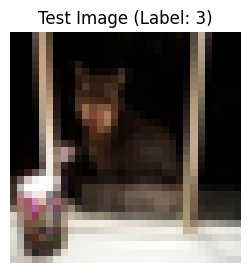

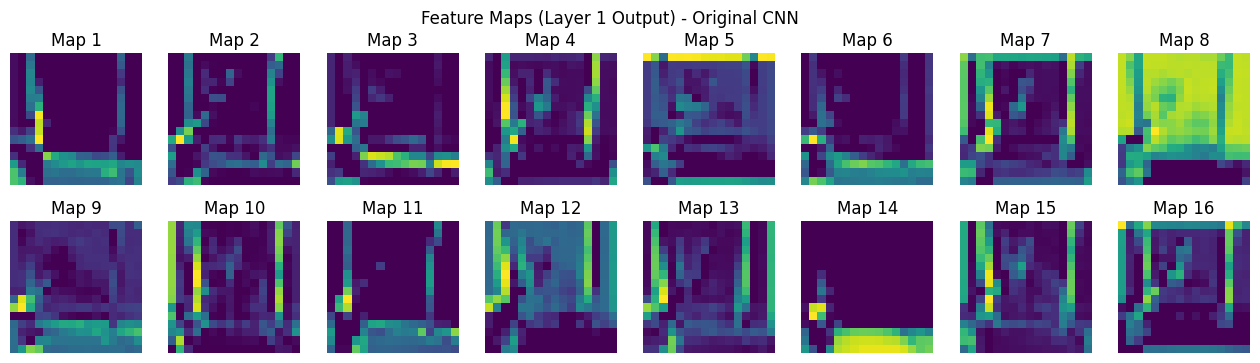

In [51]:
visualize_feature_maps(model_task1, "Original CNN", val_loader)

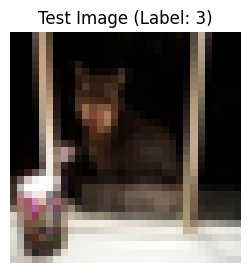

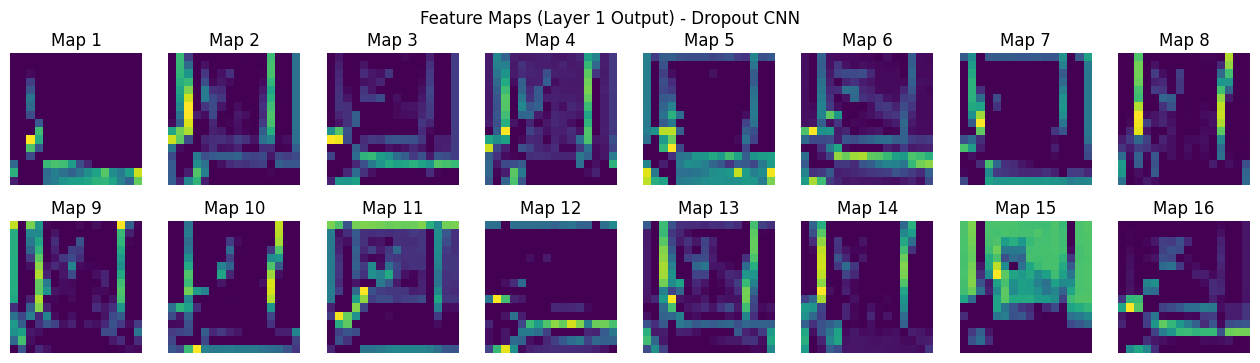

In [52]:
visualize_feature_maps(model_dropout, "Dropout CNN", val_loader)

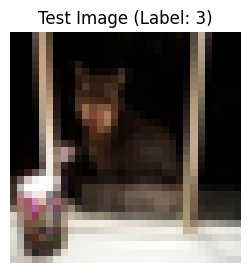

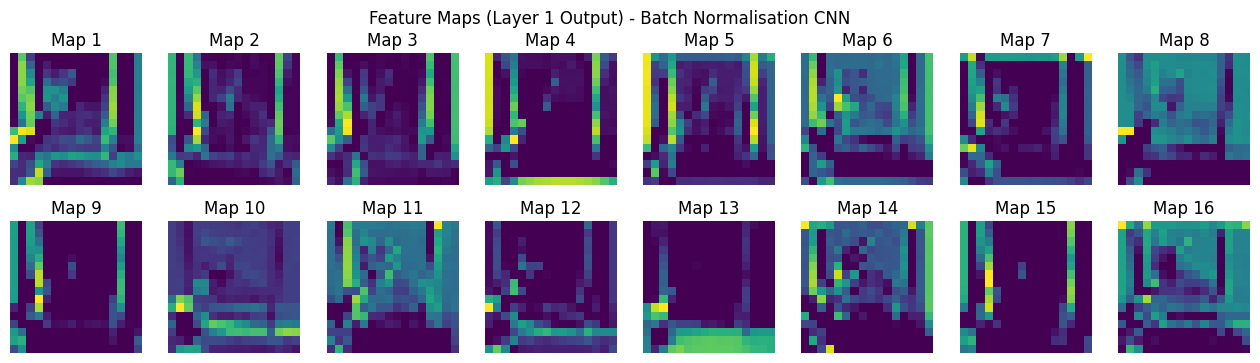

In [53]:
visualize_feature_maps(model_l2, "Batch Normalisation CNN", val_loader)

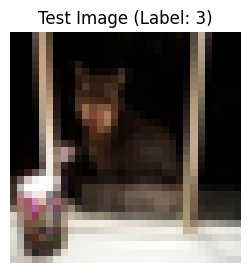

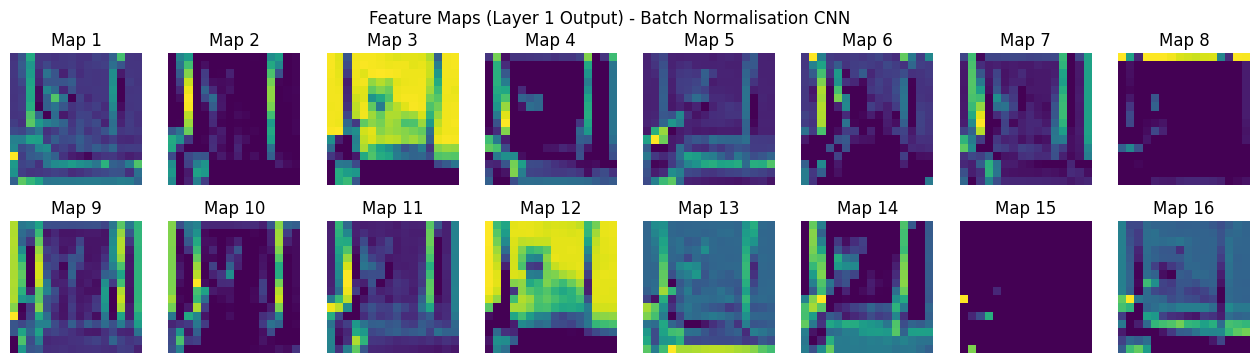

In [54]:
visualize_feature_maps(model_batchnorm, "Batch Normalisation CNN", val_loader)